In [ ]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [ ]:
import wbgapi as wb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

indicator_dict = {
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth_pc',
    'GC.DOD.TOTL.GD.ZS': 'debt_to_gdp',
    'FP.CPI.TOTL.ZG':    'inflation_rate',
    'FI.RES.TOTL.CD':    'total_reserves',
    'NE.EXP.GNFS.ZS':    'exports_pct_gdp',
    'NE.IMP.GNFS.ZS':    'imports_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_bal',
    'NY.GNS.ICTR.ZS':    'gross_savings',
    'FR.INR.RINR':       'real_interest_rate',
    'MS.MIL.XPND.GD.ZS': 'military_exp',
    'SP.POP.GROW':       'pop_growth',
    'SP.URB.TOTL.IN.ZS': 'urban_rate',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflow',
    'SH.XPD.CHEX.GD.ZS': 'health_exp',
    'EG.ELC.ACCS.ZS':    'elec_access',
    'IT.NET.USER.ZS':    'internet_use',
    'NV.IND.TOTL.ZS':    'ind_value',
    'NV.AGR.TOTL.ZS':    'agri_value',
    'SL.UEM.TOTL.ZS':    'unemployment',
    'TM.TAX.TCOM.WM.AR.ZS': 'tariff_rate',
    'NY.ADJ.AEDU.GN.ZS': 'edu_exp',
    'FB.AST.NPLN.ZS':    'bank_npl',
    'EN.ATM.CO2E.PC':    'co2_pc',
    'ER.LND.PTLD.ZS':    'protected_land',
    'SE.SEC.ENRR':       'school_enroll',
    'SI.POV.DDAY':       'poverty_rate'
}

raw_data = wb.data.DataFrame(indicator_dict.keys(), time=range(2013, 2020))

if isinstance(raw_data.index, pd.MultiIndex):
    df = raw_data.reset_index()
    df['series'] = df['series'].map(indicator_dict)
    year_cols = [c for c in df.columns if c.startswith('YR')]
    df['mean_val'] = df[year_cols].mean(axis=1)
    df = df.pivot(index='economy', columns='series', values='mean_val')
else:
    df = raw_data.groupby('economy').mean()
    df.rename(columns=indicator_dict, inplace=True)

df = df.loc[:, df.isnull().mean() < 0.4]
df = df.dropna(thresh=len(df.columns) * 0.6)
df = df.fillna(df.median())

df['crisis'] = (df['gdp_growth_pc'] < 0).astype(int)

X = df.drop(columns=['gdp_growth_pc', 'crisis'])
y_cont = df['gdp_growth_pc']
y_bin = df['crisis']

X_train_raw, X_test_raw, y_train_cont, y_test_cont, y_train_bin, y_test_bin = train_test_split(
    X, y_cont, y_bin, test_size=0.30, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Pipeline Complete")
print("Countries:", df.shape[0])
print("Predictors:", X.shape[1])
print("Crisis Base Rate:", y_bin.mean())

Pipeline Complete
Countries: 241
Predictors: 21
Crisis Base Rate: 0.06639004149377593


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ols = LinearRegression()
ols.fit(X_train, y_train_cont)

y_train_pred = ols.predict(X_train)
y_test_pred = ols.predict(X_test)

train_r2 = r2_score(y_train_cont, y_train_pred)
test_r2 = r2_score(y_test_cont, y_test_pred)
r2_gap = train_r2 - test_r2

p = X_train.shape[1]
n = X_train.shape[0]
pn_ratio = p / n

print(f"Training R2: {train_r2}")
print(f"Test R2: {test_r2}")
print(f"Train-Test R2 Gap: {r2_gap}")
print(f"Predictor-to-observation ratio (p/n): {pn_ratio}")

Training R2: 0.44049296542505945
Test R2: 0.10580468603127535
Train-Test R2 Gap: 0.3346882793937841
Predictor-to-observation ratio (p/n): 0.125


In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error

ridge = RidgeCV(alphas=np.logspace(-6, 6, 13), cv=5)
ridge.fit(X_train, y_train_cont)

lasso = LassoCV(alphas=np.logspace(-6, 6, 13), cv=5, max_iter=10000)
lasso.fit(X_train, y_train_cont)

def get_metrics(model, X_t, y_t, X_v, y_v):
    train_r2 = model.score(X_t, y_t)
    test_r2 = model.score(X_v, y_v)
    test_rmse = np.sqrt(mean_squared_error(y_v, model.predict(X_v)))
    non_zero = np.sum(model.coef_ != 0)
    return train_r2, test_r2, test_rmse, non_zero

m_ols = get_metrics(ols, X_train, y_train_cont, X_test, y_test_cont)
m_ridge = get_metrics(ridge, X_train, y_train_cont, X_test, y_test_cont)
m_lasso = get_metrics(lasso, X_train, y_train_cont, X_test, y_test_cont)

results = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'Lasso'],
    'Lambda*': [None, ridge.alpha_, lasso.alpha_],
    'Non-zero Predictors': [X.shape[1], m_ridge[3], m_lasso[3]],
    'Training R2': [m_ols[0], m_ridge[0], m_lasso[0]],
    'Test R2': [m_ols[1], m_ridge[1], m_lasso[1]],
    'Test RMSE': [m_ols[2], m_ridge[2], m_lasso[2]]
})

print(results.to_string(index=False))

Model  Lambda*  Non-zero Predictors  Training R2  Test R2  Test RMSE
  OLS      NaN                   21     0.440493 0.105805   1.910806
Ridge    100.0                   21     0.367271 0.249817   1.750185
Lasso      0.1                   14     0.396852 0.242438   1.758772


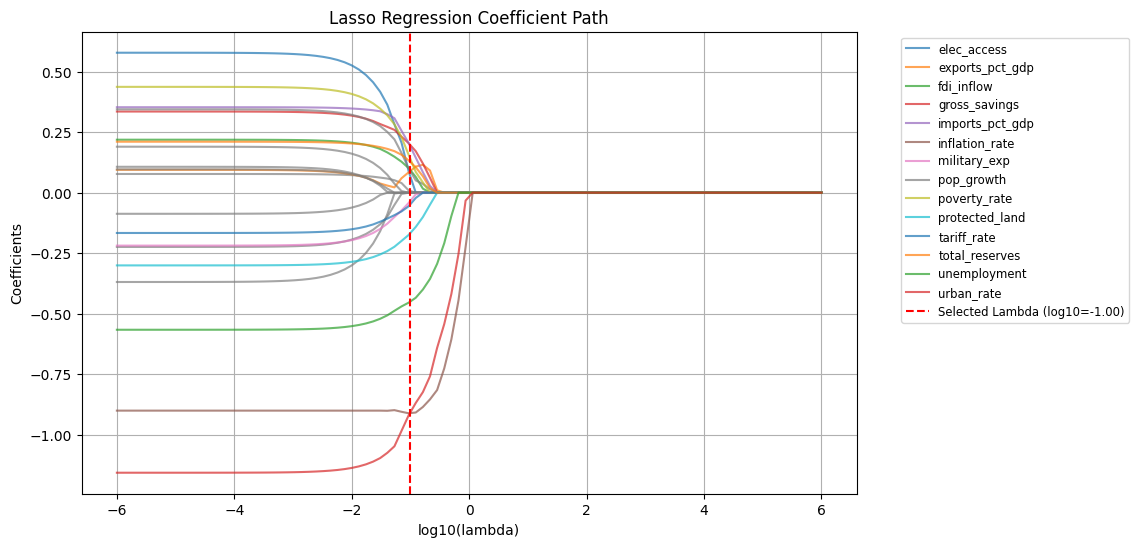

First predictor to enter the model: agri_value


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X_train, y_train_cont, alphas=np.logspace(-6, 6, 100))

plt.figure(figsize=(10, 6))
selected_lambda = lasso.alpha_
log_alphas = np.log10(alphas_path)

for i in range(coefs_path.shape[0]):
    color = 'gray' if lasso.coef_[i] == 0 else None
    plt.plot(log_alphas, coefs_path[i], label=X.columns[i] if color is None else "", color=color, alpha=0.7)

plt.axvline(np.log10(selected_lambda), color='red', linestyle='--', label=f'Selected Lambda (log10={np.log10(selected_lambda):.2f})')
plt.xlabel('log10(lambda)')
plt.ylabel('Coefficients')
plt.title('Lasso Regression Coefficient Path')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.show()

first_predictor_idx = np.argmax(np.apply_along_axis(lambda x: np.any(x != 0), 1, coefs_path[:, ::-1]))
print(f"First predictor to enter the model: {X.columns[first_predictor_idx]}")

In [ ]:
from sklearn.linear_model import LinearRegression

lpm = LinearRegression()
lpm.fit(X_train, y_train_bin)

lpm_preds = lpm.predict(X_test)

print(f"LPM Minimum Probability: {lpm_preds.min():.4f}")
print(f"LPM Maximum Probability: {lpm_preds.max():.4f}")
print(f"Out of bounds predictions (<0 or >1): {np.sum((lpm_preds < 0) | (lpm_preds > 1))}")

LPM Minimum Probability: -0.5223
LPM Maximum Probability: 0.3224
Out of bounds predictions (<0 or >1): 20


In [ ]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=10000)
logit.fit(X_train, y_train_bin)

logit_probs = logit.predict_proba(X_test)[:, 1]

print(f"Logit Minimum Probability: {logit_probs.min():.4f}")
print(f"Logit Maximum Probability: {logit_probs.max():.4f}")

Logit Minimum Probability: 0.0000
Logit Maximum Probability: 0.6663


In [ ]:
results_logit = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logit.coef_[0],
    'Odds_Ratio': np.exp(logit.coef_[0])
})

results_logit['Abs_Odds_Ratio_Log'] = np.abs(logit.coef_[0])
results_logit = results_logit.sort_values(by='Abs_Odds_Ratio_Log', ascending=False)

print(f"Intercept (beta0): {logit.intercept_[0]:.4f}")
print("\nSorted Predictors by Impact:")
print(results_logit[['Feature', 'Coefficient', 'Odds_Ratio']].to_string(index=False))

top_feature = results_logit.iloc[0]['Feature']
top_or = results_logit.iloc[0]['Odds_Ratio']

Intercept (beta0): -3.5482

Sorted Predictors by Impact:
            Feature  Coefficient  Odds_Ratio
         urban_rate     1.245291    3.473947
         pop_growth    -0.713839    0.489761
current_account_bal    -0.665372    0.514082
         health_exp    -0.665190    0.514176
          ind_value     0.648235    1.912164
       poverty_rate    -0.532051    0.587399
        elec_access    -0.494242    0.610033
    exports_pct_gdp    -0.463207    0.629263
     protected_land     0.430730    1.538380
            edu_exp    -0.415338    0.660117
     inflation_rate     0.366582    1.442795
       unemployment     0.354983    1.426157
     total_reserves    -0.342036    0.710322
      gross_savings    -0.322765    0.724144
      school_enroll    -0.254040    0.775661
         agri_value     0.241448    1.273091
       internet_use     0.211999    1.236147
       military_exp     0.195656    1.216109
         fdi_inflow    -0.142254    0.867401
        tariff_rate    -0.050166    0.95107

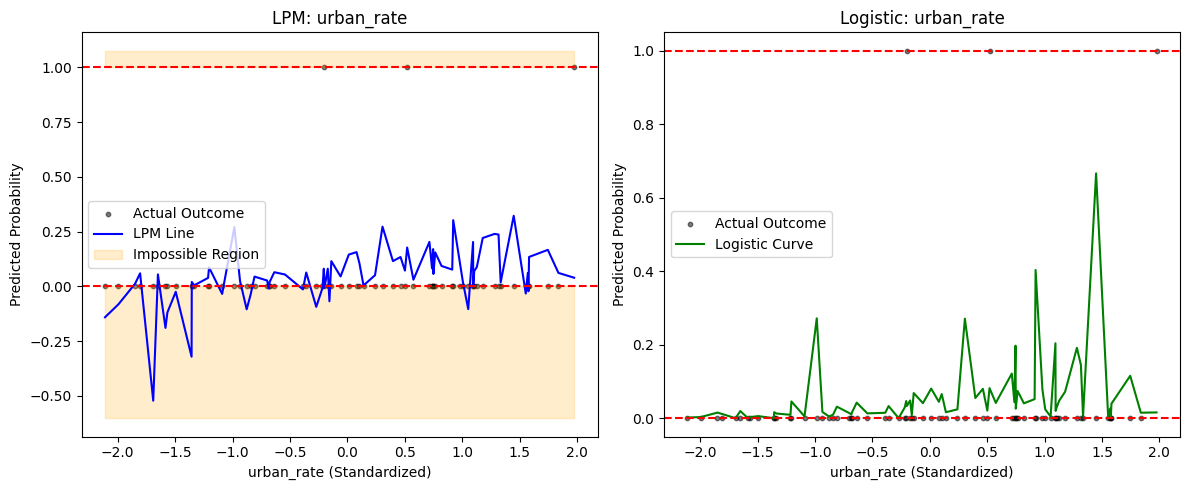

In [ ]:
plt.figure(figsize=(12, 5))

strongest_feat_idx = X.columns.get_loc(top_feature)
x_test_feat = X_test[:, strongest_feat_idx]

plt.subplot(1, 2, 1)
plt.scatter(x_test_feat, y_test_bin, color='black', s=10, label='Actual Outcome', alpha=0.5)
plt.plot(np.sort(x_test_feat), lpm.predict(X_test)[np.argsort(x_test_feat)], color='blue', label='LPM Line')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(1, color='red', linestyle='--')
plt.fill_between(np.sort(x_test_feat), 1, plt.ylim()[1], color='orange', alpha=0.2, label='Impossible Region')
plt.fill_between(np.sort(x_test_feat), plt.ylim()[0], 0, color='orange', alpha=0.2)
plt.title(f'LPM: {top_feature}')
plt.xlabel(f'{top_feature} (Standardized)')
plt.ylabel('Predicted Probability')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x_test_feat, y_test_bin, color='black', s=10, label='Actual Outcome', alpha=0.5)
sorted_idx = np.argsort(x_test_feat)
plt.plot(x_test_feat[sorted_idx], logit_probs[sorted_idx], color='green', label='Logistic Curve')
plt.axhline(0, color='red', linestyle='--')
plt.axhline(1, color='red', linestyle='--')
plt.title(f'Logistic: {top_feature}')
plt.xlabel(f'{top_feature} (Standardized)')
plt.ylabel('Predicted Probability')
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy: 0.9452


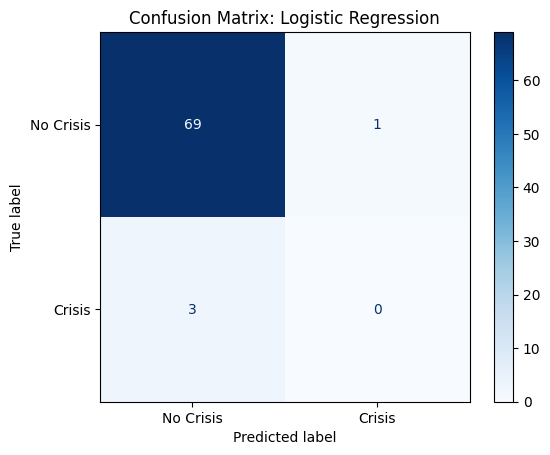

True Negatives: 69
False Positives (Type I Error): 1
False Negatives (Type II Error): 3
True Positives: 0


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

y_pred_bin = (logit_probs > 0.5).astype(int)

cm = confusion_matrix(y_test_bin, y_pred_bin)
acc = accuracy_score(y_test_bin, y_pred_bin)

print(f"Test Accuracy: {acc:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis', 'Crisis'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}")
print(f"False Positives (Type I Error): {fp}")
print(f"False Negatives (Type II Error): {fn}")
print(f"True Positives: {tp}")

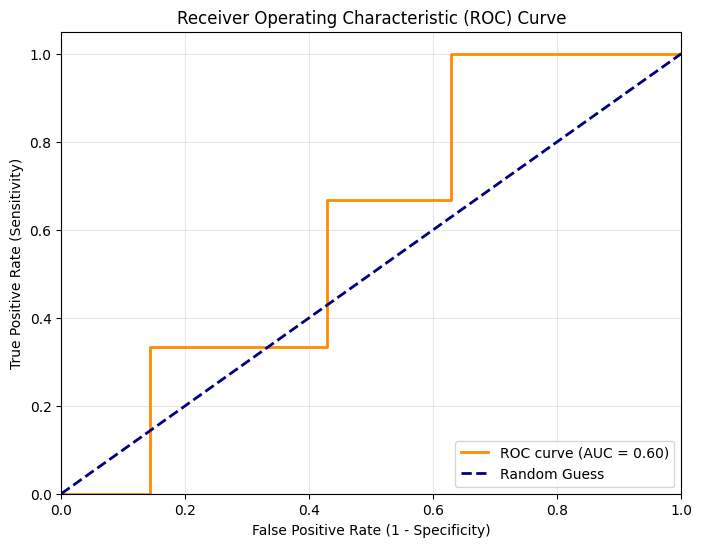

Area Under the Curve (AUC): 0.6000


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test_bin, logit_probs)
auc_score = roc_auc_score(y_test_bin, logit_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Area Under the Curve (AUC): {auc_score:.4f}")

In [ ]:
# --- Phase 3.4: The 5-Mission Constraint ---
thresholds = np.linspace(0.01, 0.99, 99)
results_34 = []

for tau in thresholds:
    flagged = (logit_probs >= tau).sum()
    results_34.append({'threshold': tau, 'flagged': flagged})

df_thresholds = pd.DataFrame(results_34)

constrained_threshold = df_thresholds[df_thresholds['flagged'] <= 5]['threshold'].min()

print(f"IMF Capacity-Constrained Threshold (max 5 missions): {constrained_threshold:.2f}")
print(f"Number of countries flagged at this threshold: {int(df_thresholds[df_thresholds['threshold'] == constrained_threshold]['flagged'].iloc[0])}")

IMF Capacity-Constrained Threshold (max 5 missions): 0.20
Number of countries flagged at this threshold: 5


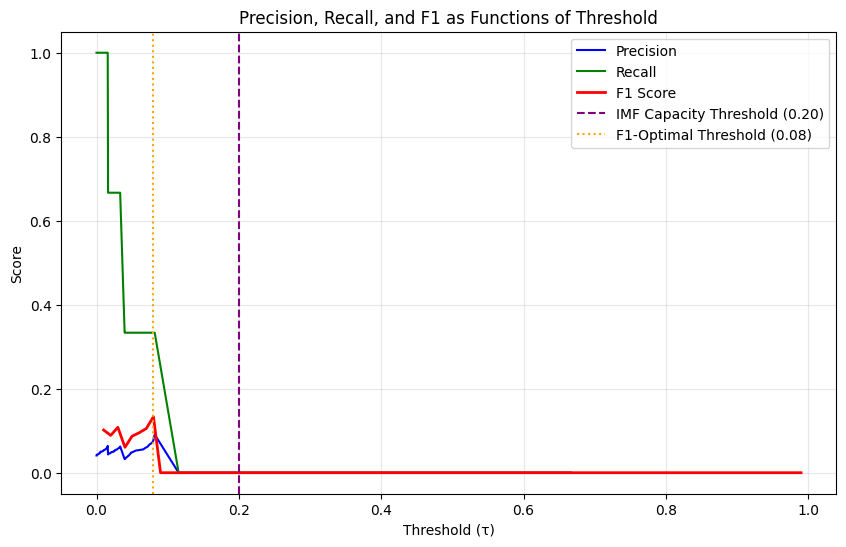

F1-Optimal Threshold: 0.08


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds_pr = precision_recall_curve(y_test_bin, logit_probs)

f1_scores = [f1_score(y_test_bin, logit_probs >= t) for t in thresholds]
f1_optimal_idx = np.argmax(f1_scores)
f1_optimal_tau = thresholds[f1_optimal_idx]

plt.figure(figsize=(10, 6))
plt.plot(thresholds_pr, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds_pr, recall[:-1], label='Recall', color='green')
plt.plot(thresholds, f1_scores, label='F1 Score', color='red', lw=2)

plt.axvline(0.20, color='purple', linestyle='--', label='IMF Capacity Threshold (0.20)')
plt.axvline(f1_optimal_tau, color='orange', linestyle=':', label=f'F1-Optimal Threshold ({f1_optimal_tau:.2f})')

plt.title('Precision, Recall, and F1 as Functions of Threshold')
plt.xlabel('Threshold (τ)')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"F1-Optimal Threshold: {f1_optimal_tau:.2f}")

In [ ]:
# Phase 4.1: Generating the Risk Dashboard DataFrame
dashboard_df = pd.DataFrame({
    'Actual_Growth': y_test_cont,
    'Crisis_Actual': y_test_bin,
    'Crisis_Probability': logit_probs
}, index=X_test_raw.index)

# Apply the capacity-constrained threshold (0.20) from Phase 3
dashboard_df['IMF_Action_Required'] = (dashboard_df['Crisis_Probability'] >= 0.20).astype(int)

# Sort by highest risk to see who gets the 5 missions
dashboard_df = dashboard_df.sort_values(by='Crisis_Probability', ascending=False)

print("Top 10 High-Risk Countries in Test Set:")
print(dashboard_df.head(10).to_string())

Top 10 High-Risk Countries in Test Set:
         Actual_Growth  Crisis_Actual  Crisis_Probability  IMF_Action_Required
economy                                                                       
LBN           0.061743              0            0.666274                    1
GRC           0.582141              0            0.403311                    1
BTN           4.871148              0            0.271833                    1
ARM           4.371429              0            0.270915                    1
PER           3.452723              0            0.203828                    1
DOM           5.954117              0            0.197361                    0
PSE           3.019393              0            0.191575                    0
TUR           4.973418              0            0.144722                    0
BGR           2.242897              0            0.121450                    0
URY           1.824339              0            0.115415                    0


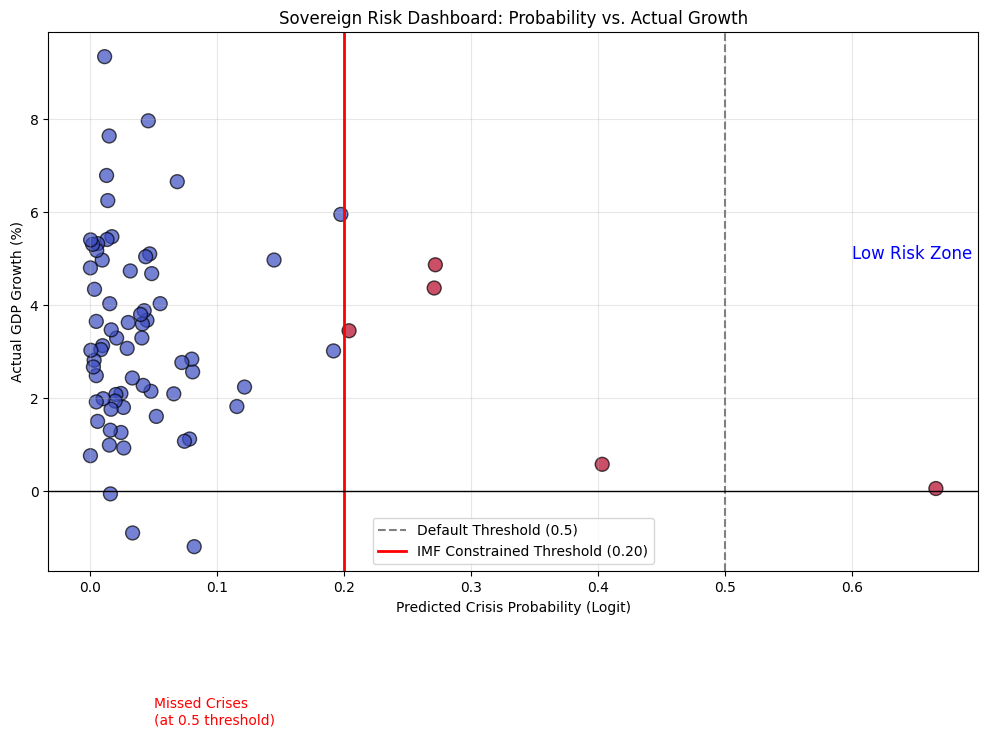

In [ ]:
# Phase 4.2: Visualizing the Intervention Zones
plt.figure(figsize=(12, 7))

# Scatter plot of Probability vs Actual Growth
plt.scatter(dashboard_df['Crisis_Probability'], dashboard_df['Actual_Growth'],
            c=dashboard_df['IMF_Action_Required'], cmap='coolwarm', s=100, edgecolors='black', alpha=0.7)

# Threshold lines
plt.axvline(0.5, color='gray', linestyle='--', label='Default Threshold (0.5)')
plt.axvline(0.20, color='red', lw=2, label='IMF Constrained Threshold (0.20)')
plt.axhline(0, color='black', lw=1)

# Zones annotation
plt.text(0.6, 5, 'Low Risk Zone', fontsize=12, color='blue')
plt.text(0.05, -5, 'Missed Crises\n(at 0.5 threshold)', fontsize=10, color='red')

plt.title('Sovereign Risk Dashboard: Probability vs. Actual Growth')
plt.xlabel('Predicted Crisis Probability (Logit)')
plt.ylabel('Actual GDP Growth (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()